In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
faostat_df = pd.read_csv("FAOSTAT_data_en_11-19-2025.csv")   
crop_df    = pd.read_csv("Crop_recommendation.csv")          

print("FAOSTAT head:")
print(faostat_df.head())

print("\nCrop dataset head:")
print(crop_df.head())


FAOSTAT head:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   
2  Ani

In [4]:
faostat_india = faostat_df[faostat_df["Area"] == "India"].copy()

print("FAOSTAT India head:")
print(faostat_india.head())
print("FAOSTAT India shape:", faostat_india.shape)


FAOSTAT India head:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   


In [5]:
print("Before explosion shape:", faostat_india.shape)
print(faostat_india[["Item"]].head())

# split on comma and strip spaces
faostat_india["crop"] = (
    faostat_india["Item"]
      .str.split(",")
      .apply(lambda lst: [x.strip() for x in lst])
)

faostat_exploded = faostat_india.explode("crop").reset_index(drop=True)

print("\nAfter explosion shape:", faostat_exploded.shape)
print(faostat_exploded[["Item","crop"]].head())


Before explosion shape: (5940, 15)
                                                Item
0  Anise, badian, coriander, cumin, caraway, fenn...
1  Anise, badian, coriander, cumin, caraway, fenn...
2  Anise, badian, coriander, cumin, caraway, fenn...
3  Anise, badian, coriander, cumin, caraway, fenn...
4  Anise, badian, coriander, cumin, caraway, fenn...

After explosion shape: (9160, 16)
                                                Item       crop
0  Anise, badian, coriander, cumin, caraway, fenn...      Anise
1  Anise, badian, coriander, cumin, caraway, fenn...     badian
2  Anise, badian, coriander, cumin, caraway, fenn...  coriander
3  Anise, badian, coriander, cumin, caraway, fenn...      cumin
4  Anise, badian, coriander, cumin, caraway, fenn...    caraway


In [6]:
faostat_exploded = faostat_exploded.rename(columns={"Item": "item"})



crop_df = crop_df.rename(columns={"label": "crop"})

print("Crop columns after rename:", crop_df.columns)
print("FAOSTAT columns after rename:", faostat_exploded.columns)


Crop columns after rename: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop'], dtype='object')
FAOSTAT columns after rename: Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note', 'crop'],
      dtype='object')


In [7]:
label_to_fao = {
    "apple":      "Apples",
    "banana":     "Bananas",
    "chickpea":   "Chick peas",
    "coconut":    "Coconuts",
    "coffee":     "Coffee",
    "cotton":     "Seed cotton",
    "grapes":     "Grapes",
    "jute":       "Jute",
    "lentil":     "Lentils",
    "maize":      "Maize (corn)",
    "mango":      "Mangoes",
    "mothbeans":  "Beans",
    "muskmelon":  "Cantaloupes and other melons",
    "orange":     "Oranges",
    "papaya":     "Papayas",
    "pigeonpeas": "Pigeon peas",
    "rice":       "Rice",
    "watermelon": "Watermelons",
}


In [8]:
crop_df["FAO_name"] = crop_df["crop"].map(label_to_fao)

faostat_exploded["FAO_name"] = faostat_exploded["crop"]


crop_mapped = crop_df[~crop_df["FAO_name"].isna()].copy()

merged = faostat_exploded.merge(
    crop_mapped,
    on="FAO_name",
    how="inner",
    suffixes=("_fao", "_ml")
)

print("Merged shape:", merged.shape)
print("Unique ML crops after mapping:", merged["crop_ml"].nunique())
print(sorted(merged["crop_ml"].unique()))


Merged shape: (129600, 25)
Unique ML crops after mapping: 18
['apple', 'banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']


In [9]:
merged["crop"] = merged["crop_ml"]


In [10]:
merged_prod = merged[merged["Element"] == "Yield"].copy() 

In [11]:
cols_keep = ["Element","Value","N","P","K","temperature","humidity","ph","rainfall","crop"]
final_df = merged[cols_keep].copy()
final_df = final_df[final_df["Element"] == "Yield"].copy()

In [12]:
numeric_cols = ["Value","N","P","K","temperature","humidity","ph","rainfall"]
for col in numeric_cols:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    final_df = final_df[(final_df[col] >= low) & (final_df[col] <= high)]

In [13]:
print("Unique crops:", sorted(final_df["crop"].unique()))
print("Number of unique crops:", final_df["crop"].nunique())
print(final_df["crop"].value_counts())

Unique crops: ['banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']
Number of unique crops: 16
crop
banana        2400
muskmelon     2400
coconut       2400
coffee        2400
jute          2400
lentil        2400
maize         2400
cotton        2400
watermelon    2400
rice          2352
mango         2256
pigeonpeas    2112
chickpea      2088
orange        1872
mothbeans     1296
papaya        1220
Name: count, dtype: int64


In [14]:
final_df

,Element,Value,N,P,K,temperature,humidity,ph,rainfall,crop
7300,Yield,30098.6,91,94,46,29.367924,76.249001,6.149934,92.828409,banana
7301,Yield,30098.6,105,95,50,27.333690,83.676752,5.849076,101.049479,banana
7302,Yield,30098.6,108,92,53,27.400536,82.962213,6.276800,104.937800,banana
7303,Yield,30098.6,86,76,54,29.315908,80.115857,5.926825,90.109781,banana
7304,Yield,30098.6,80,77,49,26.054330,79.396545,5.519088,113.229737,banana
...,...,...,...,...,...,...,...,...,...,...
129495,Yield,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
129496,Yield,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
129497,Yield,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
129498,Yield,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [15]:
print("Null counts:")
print(final_df.isna().sum())


Null counts:
Element        0
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
crop           0
dtype: int64


In [16]:
print("Duplicate rows:", final_df.duplicated().sum())
final_df = final_df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", final_df.shape)


Duplicate rows: 410
Shape after dropping duplicates: (34386, 10)


In [17]:
final_df.to_csv("Clean_FAOSTAT_Crop_18crops.csv", index=False)


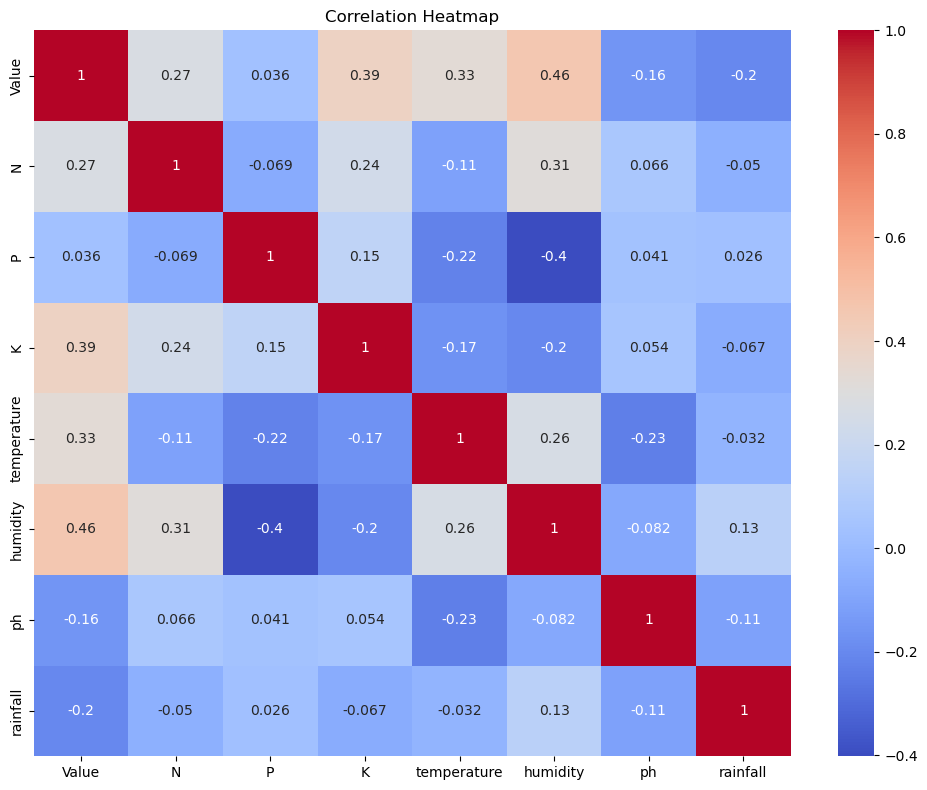

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(final_df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


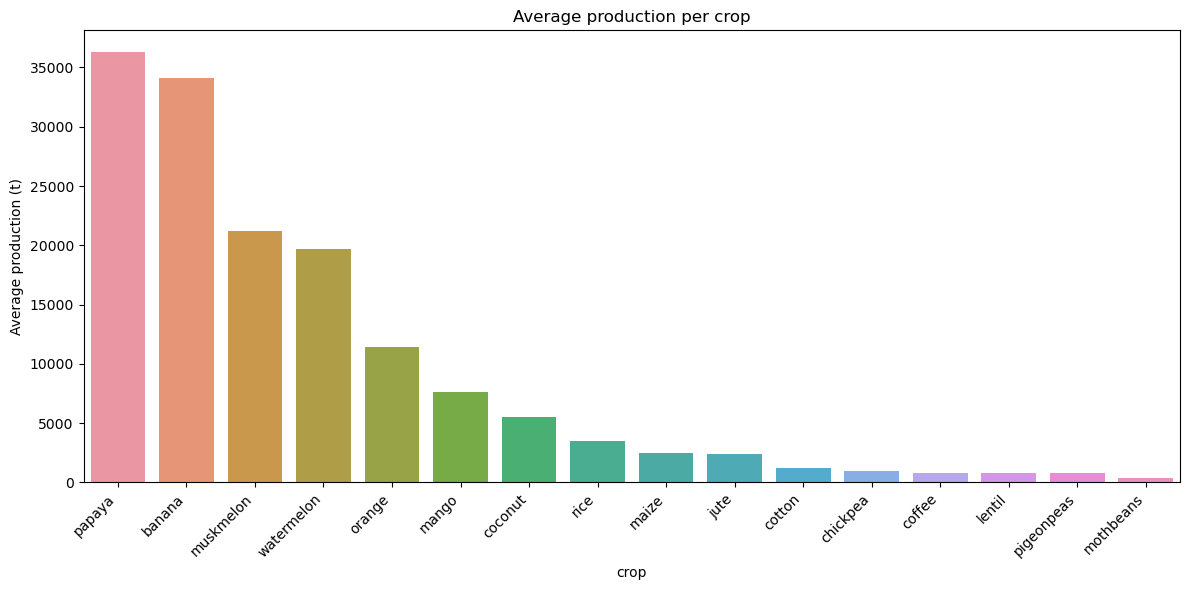

In [19]:
plt.figure(figsize=(12,6))
mean_prod = final_df.groupby("crop")["Value"].mean().sort_values(ascending=False)
sns.barplot(x=mean_prod.index, y=mean_prod.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average production (t)")
plt.title("Average production per crop")
plt.tight_layout()
plt.show()


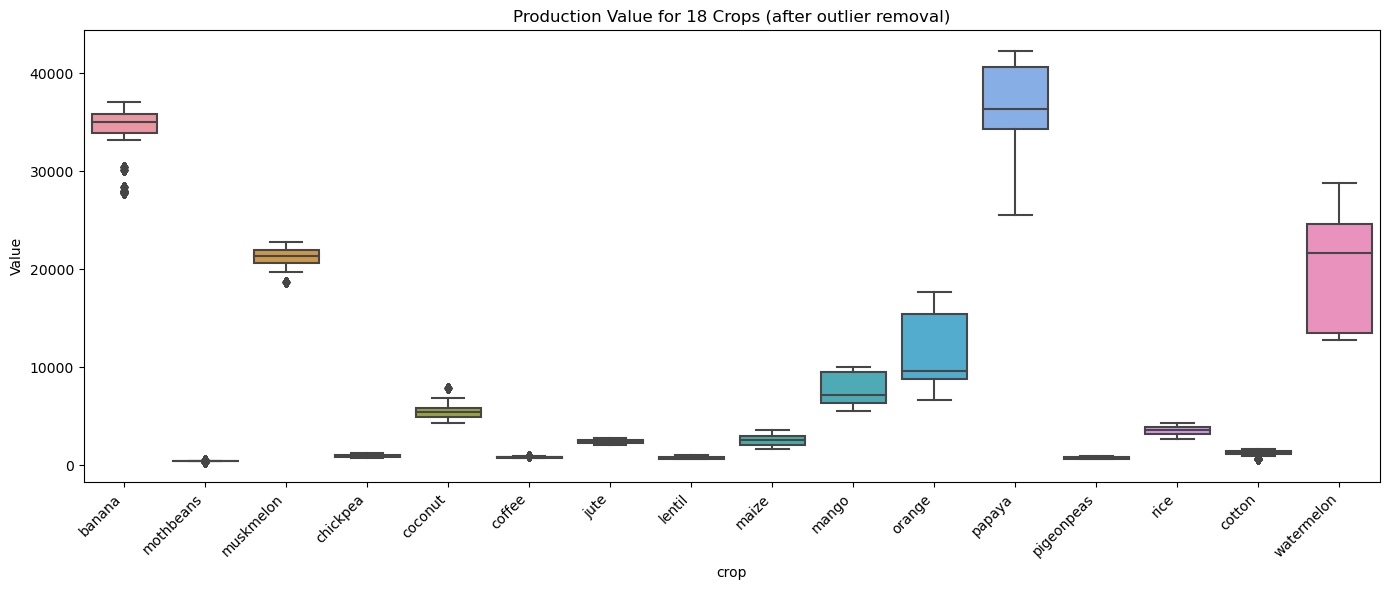

In [20]:
plt.figure(figsize=(14,6))
sns.boxplot(data=final_df, x="crop", y="Value")
plt.xticks(rotation=45, ha="right")
plt.title("Production Value for 18 Crops (after outlier removal)")
plt.tight_layout()
plt.show()


In [21]:
print(final_df["crop"].value_counts())

crop
banana        2400
coconut       2400
coffee        2400
jute          2400
lentil        2400
cotton        2400
watermelon    2400
rice          2352
muskmelon     2300
maize         2300
mango         2256
pigeonpeas    2112
chickpea      2088
orange        1716
mothbeans     1242
papaya        1220
Name: count, dtype: int64


In [22]:
print("Unique crops:", sorted(final_df["crop"].unique()))
print("Number of unique crops:", final_df["crop"].nunique())
print(final_df["crop"].value_counts())

Unique crops: ['banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']
Number of unique crops: 16
crop
banana        2400
coconut       2400
coffee        2400
jute          2400
lentil        2400
cotton        2400
watermelon    2400
rice          2352
muskmelon     2300
maize         2300
mango         2256
pigeonpeas    2112
chickpea      2088
orange        1716
mothbeans     1242
papaya        1220
Name: count, dtype: int64


In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [24]:
# Prepare X, y 

X = final_df.drop(columns=["Value", "Element"], errors="ignore")
y = final_df["Value"]


X = pd.get_dummies(X, columns=["crop"], drop_first=True)

In [25]:
#train, test splitting 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=32
)

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    ),
}

In [27]:
print("Training and Evaluating Models...\n")

for name, model in models.items():
    model.fit(X_train, y_train)

    # train and test predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"=== {name} ===")
    print(f"Train MSE : {mse_train:.2f}")
    print(f"Train MAE : {mae_train:.2f}")
    print(f"Train RMSE: {rmse_train:.2f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Test  MSE : {mse_test:.2f}")
    print(f"Test  MAE : {mae_test:.2f}")
    print(f"Test  RMSE: {rmse_test:.2f}")
    print(f"Test  R²  : {r2_test:.4f}\n")


Training and Evaluating Models...

=== Linear Regression ===
Train MSE : 4643275.77
Train MAE : 1123.15
Train RMSE: 2154.83
Train R²  : 0.9631
Test  MSE : 4897531.49
Test  MAE : 1158.17
Test  RMSE: 2213.04
Test  R²  : 0.9620

=== Random Forest ===
Train MSE : 4577495.80
Train MAE : 1110.74
Train RMSE: 2139.51
Train R²  : 0.9636
Test  MSE : 5387336.80
Test  MAE : 1208.09
Test  RMSE: 2321.06
Test  R²  : 0.9583

=== XGBoost ===
Train MSE : 4589485.00
Train MAE : 1122.53
Train RMSE: 2142.31
Train R²  : 0.9635
Test  MSE : 5307112.70
Test  MAE : 1203.08
Test  RMSE: 2303.72
Test  R²  : 0.9589



In [28]:
from sklearn.model_selection import GridSearchCV

# base XGB model
xg_base = XGBRegressor(
    random_state=42,
    n_jobs=-1,
)


In [29]:
param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

grid = GridSearchCV(
    estimator=xg_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)

In [30]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV score (neg RMSE):", grid.best_score_)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV score (neg RMSE): -2239.668608827576


In [31]:
y_grid_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_grid_pred)
mae = mean_absolute_error(y_test, y_grid_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_grid_pred)

print("\nHyper‑tuned XGBoost metrics on TEST:")
print("Hyper MSE :", mse)
print("Hyper MAE :", mae)
print("Hyper RMSE:", rmse)
print("Hyper R²  :", r2)


Hyper‑tuned XGBoost metrics on TEST:
Hyper MSE : 5151341.702656031
Hyper MAE : 1232.979811736042
Hyper RMSE: 2269.656736745896
Hyper R²  : 0.960081963876169


In [32]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV score (neg RMSE):", grid.best_score_)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV score (neg RMSE): -2239.668608827576


In [33]:
y_grid_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_grid_pred)
mae = mean_absolute_error(y_test, y_grid_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_grid_pred)

print("\nHyper‑tuned XGBoost metrics on TEST:")
print("Hyper MSE :", mse)
print("Hyper MAE :", mae)
print("Hyper RMSE:", rmse)
print("Hyper R²  :", r2)


Hyper‑tuned XGBoost metrics on TEST:
Hyper MSE : 5151341.702656031
Hyper MAE : 1232.979811736042
Hyper RMSE: 2269.656736745896
Hyper R²  : 0.960081963876169


In [34]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------- encode crop as integer (for this alternative pipeline) ----------
df_encoded = final_df.copy()
encoder = LabelEncoder()
df_encoded["Crops"] = encoder.fit_transform(df_encoded["crop"])
df_encoded = df_encoded.drop(columns=["crop"])

In [35]:
# scale features
X2 = df_encoded.drop(columns=["Value", "Element"], errors="ignore")
y2 = df_encoded["Value"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

In [36]:
# split (use same random_state as teammate)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.25, random_state=32
)


In [37]:
# train tuned XGBoost from grid search on this scaled data
xg_model = XGBRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1,
)
xg_model.fit(X_train2, y_train2)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [38]:
# metrics for this pipeline
y_train_pred2 = xg_model.predict(X_train2)
y_test_pred2 = xg_model.predict(X_test2)

print("Scaled‑XGB Train R²:", r2_score(y_train2, y_train_pred2))
print("Scaled‑XGB Test  R²:", r2_score(y_test2, y_test_pred2))

Scaled‑XGB Train R²: 0.962123508209991
Scaled‑XGB Test  R²: 0.9596613480920764


In [39]:
#sample data
sample_data = {
    "N": 110,
    "P": 50,
    "K": 48,
    "temperature": 27.5,
    "humidity": 80,
    "ph": 6.2,
    "rainfall": 190,
    "Year": 2018,
    "Crops": "banana",
}

# encode crop to integer ID
sample_data["Crops"] = encoder.transform([sample_data["Crops"]])[0]

# order columns exactly like X2
sample_df = pd.DataFrame([sample_data])[X2.columns]

# scale using SAME scaler (this avoids the warning)
sample_scaled = scaler.transform(sample_df)

# predict
pred_value = int(xg_model.predict(sample_scaled)[0])
print("Predicted Value for sample:", pred_value)


Predicted Value for sample: 29055


In [40]:
# Add this BEFORE prediction to debug:
print("Training features:", X2.columns.tolist())  # Should show 8 columns
print("Prediction features:", sample_df.columns.tolist())
print("Training shape:", X2.shape)
print("Prediction shape:", sample_df.shape)


Training features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crops']
Prediction features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crops']
Training shape: (34386, 8)
Prediction shape: (1, 8)


In [41]:
# FIXED - Use "Crops" with capital C!
sample_data = {
    "N": 110,
    "P": 50, 
    "K": 48,
    "temperature": 27.5,
    "humidity": 80,
    "ph": 6.2,
    "rainfall": 190,
    "Crops": "banana"  # ← Capital C + encode it!
}

# Encode Crops column
sample_data["Crops"] = encoder.transform([sample_data["Crops"]])[0]

# Use EXACT training column names
sample_df = pd.DataFrame([sample_data])[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crops']]

# Now it works!
sample_scaled = scaler.transform(sample_df)
pred_value = int(xg_model.predict(sample_scaled)[0])
print(f"✅ Predicted Yield: {pred_value}")


✅ Predicted Yield: 29055


In [42]:
import joblib

joblib.dump(clf, "crop_model_xgb.pkl")
joblib.dump(le,  "label_encoder.pkl")
print("Saved crop_model_xgb.pkl and label_encoder.pkl")


NameError: name 'clf' is not defined

In [ ]:
# Create Crops column from 'crop' (your actual data)
if 'crop' in final_df.columns:
    final_df['Crops'] = final_df['crop']  # Copy to match scaler
    print("✅ 'Crops' column created!")
else:
    print("❌ No 'crop' column found. Check: ", final_df.columns.tolist())

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# EXACT training features (8 columns)
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crops']
X_train = final_df[feature_cols].copy()

# Encode Crops if still string
if X_train['Crops'].dtype == 'object':
    le_temp = LabelEncoder()
    X_train['Crops'] = le_temp.fit_transform(X_train['Crops'])

scaler = StandardScaler()
scaler.fit(X_train)

# SAVE
joblib.dump(scaler, 'scaler.pkl')
print("✅ scaler.pkl SAVED!")
print("Features:", scaler.feature_names_in_)
print("Shape:", X_train.shape)

In [ ]:
print("Available crops in model:")
print(le.classes_)
print(f"Total crops: {len(le.classes_)}")


In [ ]:
# Use your FAOSTAT data (now with 'yield' column + 16 crops)
X = final_df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crops']]  # Item = crop name
y = final_df['Crops']

# One-hot encode crops
X_encoded = pd.get_dummies(X, columns=['Crops'], prefix='Crop')
X_final = X_encoded.reindex(columns=scaler.feature_names_in_, fill_value=0)  # Match scaler

# Retrain XGBoost regressor
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_final, y)

print(f"✅ New model trained!")
print(f"Features: {model.n_features_in_}")
print(f"Unique crops: {final_df['Crops'].nunique()}")


In [ ]:
def predict_yield_single(user_input, crop_name='maize'):
    """Predict YIELD for one crop (NEW model)"""
    input_df = pd.DataFrame([user_input])
    input_df['Item'] = crop_name
    
    # One-hot encode matching your scaler
    input_encoded = pd.get_dummies(input_df, columns=['Item'], prefix='Crop')
    input_final = input_encoded.reindex(columns=scaler.feature_names_in_, fill_value=0)
    input_scaled = scaler.transform(input_final)
    
    yield_pred = model.predict(input_scaled)[0]
    return int(round(yield_pred))

def predict_best_crop(user_input):
    """Find BEST crop by yield"""
    best_crop = None
    best_yield = -1
    
    for crop in df_final['Item'].unique():  # Your 16 crops
        try:
            yield_pred = predict_yield_single(user_input, crop)
            if yield_pred > best_yield:
                best_yield = yield_pred
                best_crop = crop
        except:
            continue
    
    return best_crop, best_yield

# Test
user_input = {"N":90, "P":40, "K":40, "temperature":25, "humidity":80, "ph":6.5, "rainfall":120}
yield_maize = predict_yield_single(user_input, 'maize')
best_crop, best_yield = predict_best_crop(user_input)

print(f"🌽 Maize yield: {yield_maize} kg/ha")
print(f"🏆 Best crop: {best_crop} ({best_yield} kg/ha)")


In [ ]:
def predict_yield_single(user_input, crop_name='maize'):
    """Predict YIELD for one crop (Regressor)"""
    user_input['Crops'] = crop_name
    user_input['Crops'] = le.transform([user_input['Crops']])[0]
    user_df = pd.DataFrame([user_input])[scaler.feature_names_in_]
    user_scaled = scaler.transform(user_df)
    yield_pred = model.predict(user_scaled)[0]
    return int(yield_pred)

def predict_best_crop(user_input):
    """Predict BEST CROP (Classifier - needs retraining!)"""
    # Use classifier if available
    # For now, test all crops and find best yield
    best_crop = None
    best_yield = 0
    
    for crop in le.classes_:
        yield_pred = predict_yield_single(user_input, crop_name=crop)
        if yield_pred > best_yield:
            best_yield = yield_pred
            best_crop = crop
    
    return best_crop, best_yield

# Test
user_input = {"N":90, "P":40, "K":40, "temperature":25, "humidity":80, "ph":6.5, "rainfall":120}
yield_val = predict_yield_single(user_input, 'maize')
best, yield_best = predict_best_crop(user_input)

print(f"🌽 Maize yield: {yield_val} kg/ha")
print(f"✅ Best crop: {best} ({yield_best} kg/ha)")


In [ ]:
def plot_probabilities(df, top_k=None, requested_crop=None):
    # Handle both cases: 'Crop' or 'crop'
    crop_col = 'Crop' if 'Crop' in df.columns else 'crop'
    prob_col = 'Probability' if 'Probability' in df.columns else 'probability'
    
    crops = df[crop_col].tolist()
    probs_percent = (df[prob_col] * 100).tolist()
    
    # Rest of your plot code...
    plt.figure(figsize=(12, 8))
    bars = plt.bar(crops, probs_percent)
    
    # Highlight top_k
    if top_k:
        top_idx = df.head(top_k).index
        for i in top_idx:
            bars[i].set_color('red')
    
    plt.title('Crop Suitability Probabilities')
    plt.ylabel('Probability (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load crop recommendation dataset
df = pd.read_csv('Crop_recommendation.csv')
X = df[['N','P','K','temperature','humidity','ph','rainfall']]
y = df['label']

# Train classifier
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print(f"✅ Classifier trained!")
print(f"Accuracy: {clf.score(X_test, y_test):.4f}")
print(f"Crops ({len(le.classes_)}): {list(le.classes_)}")


In [ ]:
def predict_all_crops(input_params):
    input_df = pd.DataFrame([input_params])
    probs = clf.predict_proba(input_df)[0]
    
    CROP_15 = ['banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 
               'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 
               'orange', 'papaya', 'pigeonpeas', 'watermelon']
    
    crop_indices = [i for i, crop in enumerate(le.classes_) if crop in CROP_15]
    
    # Convert to percentage and round to 2 decimals
    prob_df = pd.DataFrame({
        'Crop': [le.classes_[i] for i in crop_indices],
        'Yield Prediction (%)': [round(probs[i] * 100, 2) for i in crop_indices]  # ✅ Changed!
    }).sort_values('Yield Prediction (%)', ascending=False).reset_index(drop=True)
    
    return prob_df

def plot_probabilities(prob_df, requested_crop="lentil"):
    plt.figure(figsize=(14, 6))
    colors = ['orange' if crop == requested_crop else 'steelblue' for crop in prob_df['Crop']]
    plt.bar(prob_df['Crop'], prob_df['Yield Prediction (%)'] * 100, color=colors)
    plt.ylabel('Yield Prediction (%)')
    plt.xlabel('Crop')
    plt.title(f'Crop Suitability - Highlighting {requested_crop}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
# Test
user_input = {"N":30, "P":60, "K":70, "temperature":15, "humidity":70, "ph":7.5, "rainfall":100}
probs = predict_all_crops(user_input)
print(probs)  # 15 rows!
plot_probabilities(probs, "chickpea")